# 05 - Evaluation
**CRISP-DM phase:** Evaluation

This notebook judges the final models from notebook 04 against the success criteria set in notebook 01:
1. Every model beats its baseline on **untouched test data** (CRSS 2024; complaints 2024-2026).
2. No material **overfitting** (train vs validation gaps, learning curves) and acceptable **stability over time** (validation vs test).
3. Results are **explainable**: what drives each prediction.
4. Each research question RQ1-RQ5 is answered.

The crash models evaluated here are the **final** S1 (15 features, 13 fields) and S2 (75 features, 47 fields) models from notebook 04, Part C: the same models the application deploys. The benchmark models (all 1,456 features) appear only for comparison in 5.6.

**Two metrics, two jobs.** PR-AUC is the headline and selection metric because it focuses on the class we care about and its no-skill baseline equals that class's share. ROC-AUC is used for the overfitting, stability and survey-weight checks because it does not depend on how common the outcome is. They are on different scales, so the same model can have a PR-AUC of 0.896 and a ROC-AUC of 0.874 without any conflict.

Test results were calculated after the relevant decisions were fixed and were not used to select features, hyperparameters or thresholds.

## 5.0 Setup

In [1]:
from pathlib import Path
import json, sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from project_paths import CRSS_TEST_YEAR, EVALUATION_DIR, FIGURE_DIR, OUTPUT_DIR, PROCESSED_DIR, TABLE_DIR, crss_extracted_dir

pd.set_option("display.max_columns", 40, "display.width", 220, "display.precision", 3)
load = lambda name: pd.read_csv(EVALUATION_DIR / name)
FINAL_DIR = EVALUATION_DIR / "final"
CRASH = ("y_injury", "y_serious")

# Final crash models (notebook 04, Part C) and the text models
final = {t: pd.read_csv(FINAL_DIR / f"crss_{t}_final_results.csv") for t in CRASH}
text = {t: load(f"text_{t}_model_comparison.csv") for t in ("U1", "U2")}
selected = {t: r[r.model != "Dummy (prior)"].iloc[0] for t, r in final.items()}
selected |= {t: r[r.selected].iloc[0] for t, r in text.items()}
dummy = {t: r[r.model == "Dummy (prior)"].iloc[0] for t, r in (final | text).items()}
# Benchmark crash models (all fields), used only for comparison in 5.6
benchmark = {t: load(f"crss_{t}_model_comparison.csv") for t in CRASH}

## 5.1 Headline results on untouched test data
The test period was never used for training, tuning, threshold choice or model selection.

**U1 baseline.** U1 is judged by top-1 accuracy (is the highest-ranked group one of the complaint's true groups?). Its no-skill baseline is to always choose the group that is most common in the training years; the cell below computes that on the same test complaints.

In [2]:
cm = pd.read_parquet(PROCESSED_DIR / "complaints_model.parquet")
groups = [c for c in cm.columns if c.startswith("c__")]
cm = cm[(cm.year >= 2010) & (cm[groups].sum(axis=1) > 0)]
most_common = cm.loc[cm.split == "train", groups].sum().idxmax()
u1_base_top1 = cm.loc[cm.split == "test", most_common].mean()
u1_base = cm.loc[cm.split == "test", groups].values
pred = np.zeros_like(u1_base); pred[:, groups.index(most_common)] = 1
from sklearn.metrics import f1_score
u1_base_macro = f1_score(u1_base, pred, average="macro", zero_division=0)
print(f"U1 baseline: always '{most_common[3:]}' -> test top-1 accuracy {u1_base_top1:.1%}, macro-F1 {u1_base_macro:.3f}")
del cm, u1_base, pred

headline = pd.DataFrame([
    {"model": "S1 injury crash", "selected": f"{selected['y_injury'].model}, {int(selected['y_injury'].n_features)} features",
     "metric": "PR-AUC", "baseline": dummy["y_injury"].test_pr_auc, "test": selected["y_injury"].test_pr_auc,
     "test ROC-AUC": selected["y_injury"].test_roc_auc},
    {"model": "S2 serious/fatal crash", "selected": f"{selected['y_serious'].model}, {int(selected['y_serious'].n_features)} features",
     "metric": "PR-AUC", "baseline": dummy["y_serious"].test_pr_auc, "test": selected["y_serious"].test_pr_auc,
     "test ROC-AUC": selected["y_serious"].test_roc_auc},
    {"model": "U1 component routing", "selected": selected["U1"].model, "metric": "top-1 accuracy",
     "baseline": u1_base_top1, "test": selected["U1"].test_top1_accuracy, "test ROC-AUC": None},
    {"model": "U1 component routing", "selected": selected["U1"].model, "metric": "macro-F1",
     "baseline": u1_base_macro, "test": selected["U1"].test_macro_f1, "test ROC-AUC": None},
    {"model": "U2 serious-incident flag", "selected": selected["U2"].model, "metric": "PR-AUC",
     "baseline": dummy["U2"].validation_pr_auc, "test": selected["U2"].test_pr_auc, "test ROC-AUC": selected["U2"].test_roc_auc},
])
headline

U1 baseline: always 'ELECTRICAL' -> test top-1 accuracy 21.1%, macro-F1 0.018


,model,selected,metric,baseline,test,test ROC-AUC
0,S1 injury crash,"Gradient Boosting (final), 15 features",PR-AUC,0.513,0.894,0.872
1,S2 serious/fatal crash,"Gradient Boosting (final), 75 features",PR-AUC,0.130,0.610,0.889
2,U1 component routing,Linear SVM,top-1 accuracy,0.211,0.844,NaN
3,U1 component routing,Linear SVM,macro-F1,0.018,0.691,NaN
4,U2 serious-incident flag,Linear SVM,PR-AUC,0.064,0.858,0.965


**Interpretation.** All four models far exceed their baselines on data from a later period than they were trained on. S1 reaches PR-AUC 0.894 against 0.513 and S2 0.610 against 0.130 (4.7 times the baseline), using 15 and 75 features. U1 picks a correct group for 84.4% of test complaints, against 21.1% for always choosing the most common group (Electrical). U2's baseline is the validation share of serious complaints.

## 5.2 Overfitting check: training vs validation
A model that memorises its training data scores much higher on training than on validation. First the final crash models, then every benchmark and text candidate for comparison (ROC-AUC for the crash models, macro-F1 for U1, PR-AUC for U2).

In [3]:
fin_gap = pd.DataFrame([{"task": t, "model": "final " + selected[t].model, "train ROC-AUC": final[t].iloc[1].train_roc_auc,
                         "validation ROC-AUC": selected[t].validation_roc_auc,
                         "gap": selected[t].overfit_gap_auc_train_minus_val} for t in CRASH])
display(fin_gap)
gaps = []
for t, r in (benchmark | text).items():
    r = r[r.model != "Dummy (prior)"]
    metric = "macro_f1" if t == "U1" else ("pr_auc" if t == "U2" else "roc_auc")
    for _, x in r.iterrows():
        gaps.append({"task": t if t in ("U1", "U2") else f"{t} (benchmark)", "model": x.model,
                     "gap": x[f"train_{metric}"] - x[f"validation_{metric}"]})
pd.DataFrame(gaps).pivot_table(index=["task", "model"], values="gap", aggfunc="max").round(3)

,task,model,train ROC-AUC,validation ROC-AUC,gap
0,y_injury,final Gradient Boosting (final),0.864,0.874,-0.010
1,y_serious,final Gradient Boosting (final),0.921,0.890,0.031


gap
task                  model                        
U1                    Complement Naive Bayes  0.077
                      Linear SVM              0.066
                      Logistic Regression     0.124
U2                    Complement Naive Bayes  0.053
                      Linear SVM              0.076
                      Logistic Regression     0.102
y_injury (benchmark)  Decision Tree           0.009
                      Gradient Boosting       0.022
                      Logistic Regression    -0.004
                      Random Forest           0.081
y_serious (benchmark) Decision Tree           0.030
                      Gradient Boosting       0.050
                      Logistic Regression     0.029
                      Random Forest           0.111

**Interpretation.** The final crash models show no material overfitting: S1 scores slightly *higher* on validation than on training (gap −0.010), and S2's gap is 0.031. Among the benchmark candidates, Random Forest showed by far the largest gaps (0.08 for S1, 0.11 for S2) because its deep trees memorise individual crashes, which is why it was not selected. For the text models, Logistic Regression fits the training text more tightly than Linear SVM, one reason the SVM is selected.

### Learning curves
Each final model is refitted on growing fractions of the training data. Overfitting appears as a training curve far above a flat validation curve; healthy learning appears as the two curves converging, with validation still rising as data is added. The crash figures also show calibration (right-hand panels).

crss_y_injury_final_diagnostics.png


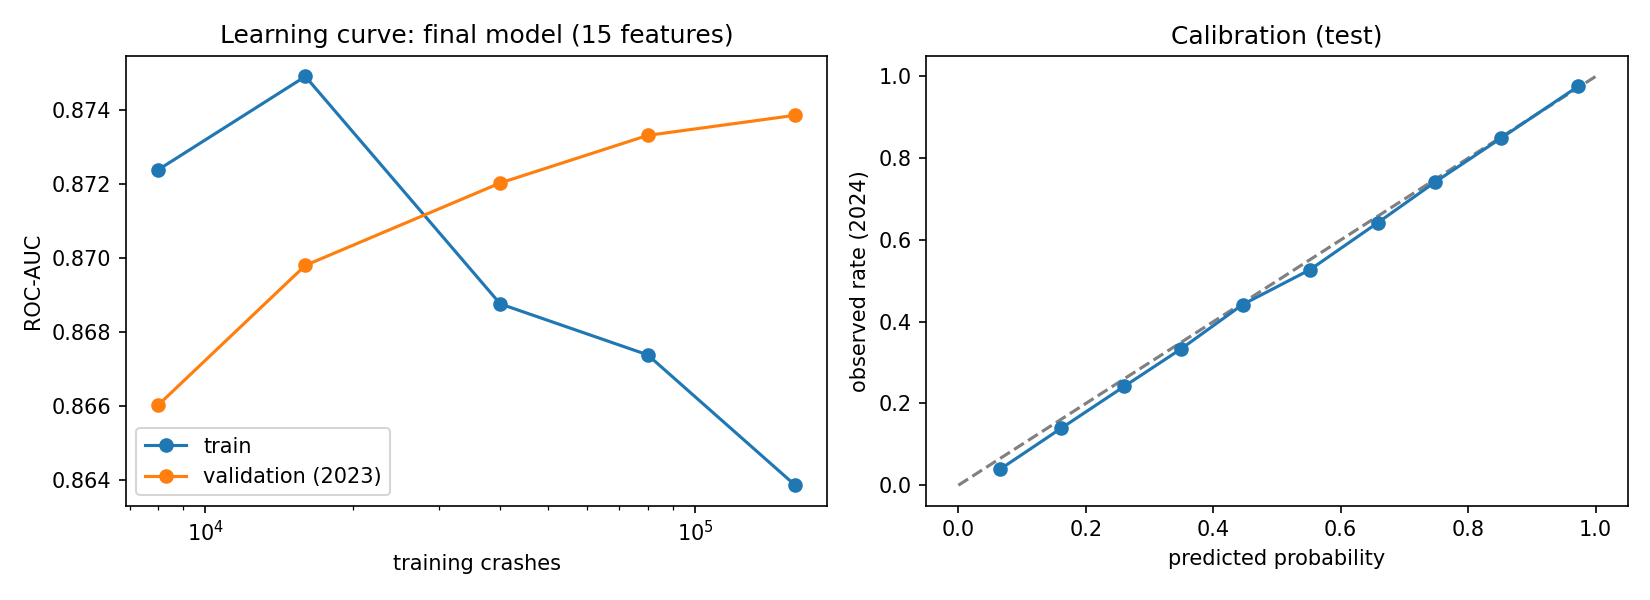

crss_y_serious_final_diagnostics.png


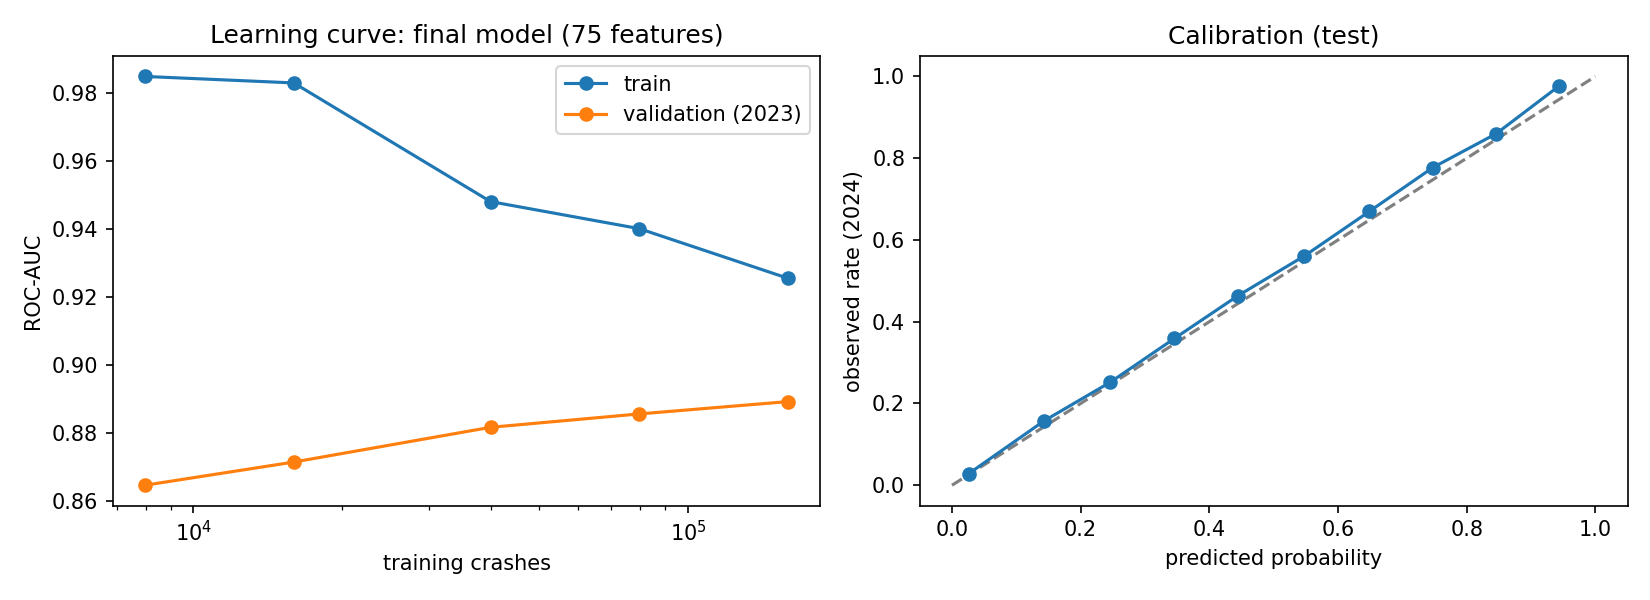

text_U2_learning_curve.png


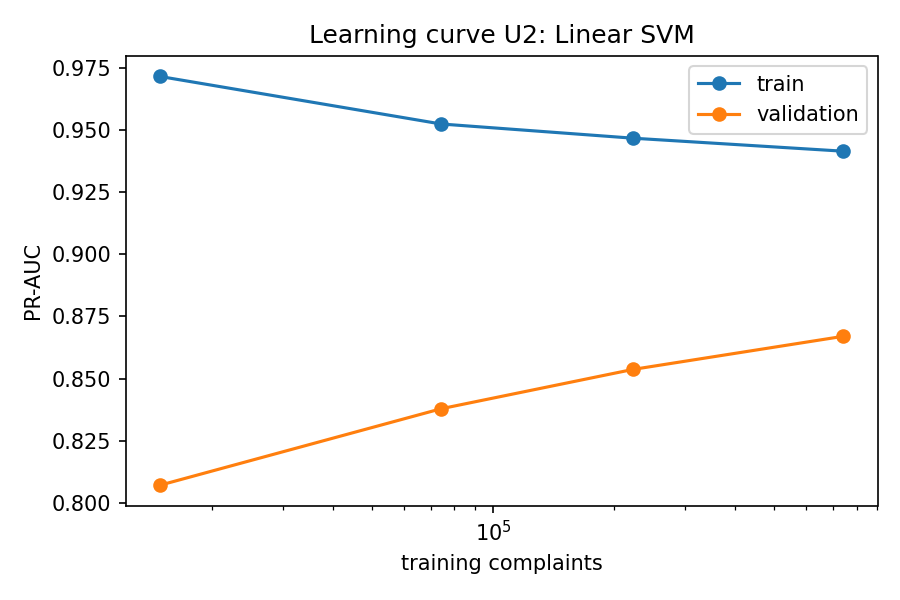

text_U1_learning_curve.png


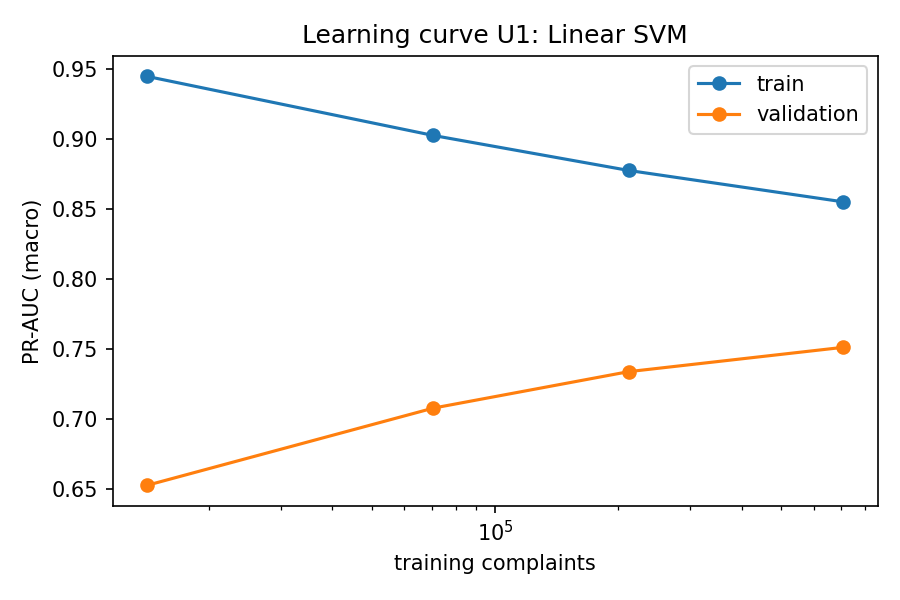

In [4]:
for f in [FINAL_DIR / "crss_y_injury_final_diagnostics.png", FINAL_DIR / "crss_y_serious_final_diagnostics.png",
          EVALUATION_DIR / "text_U2_learning_curve.png", EVALUATION_DIR / "text_U1_learning_curve.png"]:
    print(f.name); display(Image(filename=str(f), width=760))

In [5]:
curves = {t: pd.read_csv(FINAL_DIR / f"crss_{t}_final_learning_curve.csv") for t in CRASH}
curves |= {t: load(f"text_{t}_learning_curve.csv") for t in ("U1", "U2")}
for t, c in curves.items():
    c = c.copy(); c.columns = ["train_rows", "train", "validation"]
    c["gap"] = c.train - c.validation
    print(t); display(c.round(3))

y_injury


,train_rows,train,validation,gap
0,7996,0.872,0.866,0.006
1,15992,0.875,0.870,0.005
2,39980,0.869,0.872,-0.003
3,79960,0.867,0.873,-0.006
4,159920,0.864,0.874,-0.010


y_serious


,train_rows,train,validation,gap
0,7975,0.985,0.865,0.120
1,15951,0.983,0.871,0.112
2,39879,0.948,0.882,0.066
3,79758,0.940,0.886,0.055
4,159516,0.925,0.889,0.036


U1


,train_rows,train,validation,gap
0,14127,0.945,0.653,0.292
1,70637,0.903,0.708,0.195
2,211913,0.878,0.734,0.144
3,706377,0.855,0.751,0.104


U2


,train_rows,train,validation,gap
0,14832,0.971,0.807,0.164
1,74162,0.952,0.838,0.114
2,222486,0.947,0.854,0.093
3,741623,0.941,0.867,0.074


**Interpretation.** In every case the validation score keeps rising as training data grows and the gap stays small or shrinks: S2's gap closes from 0.12 at 8,000 crashes to 0.04 at 160,000, and S1's curves sit almost on top of each other. The models are limited by data, not memorising it, which also justifies using the full data volume.

## 5.3 Stability over time: validation vs test
Validation and test come from different years. Similar scores mean the model holds up as time moves on; a large drop would signal drift.

In [6]:
stab = []
for t in ("y_injury", "y_serious", "U2"):
    s = selected[t]
    stab.append({"task": t, "model": s.model, "validation ROC-AUC": s.validation_roc_auc, "test ROC-AUC": s.test_roc_auc,
                 "validation PR-AUC": s.validation_pr_auc, "test PR-AUC": s.test_pr_auc})
s = selected["U1"]
stab.append({"task": "U1", "model": s.model, "validation PR-AUC": s.validation_macro_pr_auc, "test PR-AUC": s.test_macro_pr_auc})
pd.DataFrame(stab)

,task,model,validation ROC-AUC,test ROC-AUC,validation PR-AUC,test PR-AUC
0,y_injury,Gradient Boosting (final),0.874,0.872,0.896,0.894
1,y_serious,Gradient Boosting (final),0.890,0.889,0.620,0.610
2,U2,Linear SVM,0.965,0.965,0.867,0.858
3,U1,Linear SVM,NaN,NaN,0.751,0.725


**Interpretation.** The final crash models are essentially unchanged from 2023 to 2024 (ROC-AUC differs by about 0.001). The text models drop slightly from 2022-23 to 2024-26, as expected: the complaint mix keeps shifting (notebook 02: driver-assistance and engine complaints rising), which the deployment plan addresses with periodic retraining.

## 5.4 Decisions at the chosen threshold (S1, S2)

In [7]:
for t in CRASH:
    cmat = pd.read_csv(FINAL_DIR / f"crss_{t}_final_confusion_test.csv", index_col=0)
    tn, fp, fn, tp = cmat.values.ravel()
    print(f"{t}: threshold {selected[t].threshold:.3f} | recall {tp/(tp+fn):.1%} | precision {tp/(tp+fp):.1%}")
    display(cmat)

y_injury: threshold 0.405 | recall 78.3% | precision 80.9%


,pred 0,pred 1
actual 0,19911,4821
actual 1,5661,20388


y_serious: threshold 0.252 | recall 62.9% | precision 50.4%


,pred 0,pred 1
actual 0,39994,4075
actual 1,2442,4143


**Interpretation.** Thresholds were chosen on validation to maximise F1, a balance of catching positives (recall) and avoiding false alarms (precision). At these thresholds S1 catches 78% of injury crashes with 81% precision, and S2 catches 63% of serious or fatal crashes, with half of its flags correct. In use, the threshold is a policy choice: an analyst prioritising serious crashes could lower it to catch more at the cost of more reviews.

## 5.5 Calibration and the survey design
Calibration asks whether a predicted 30% really means about 30% of such crashes are positive (right-hand panels of the diagnostics figures above). CRSS deliberately **over-samples injury crashes**: the sample injury rate is about 51%, while the survey-weighted national rate is about 28% (notebook 02). Model probabilities are therefore calibrated to the **sample**, and the application states this. Weighted ROC-AUC on the test year (using CRSS weights) checks that ranking quality holds at national scale.

In [8]:
pd.DataFrame([{"task": t, "test ROC-AUC (sample)": selected[t].test_roc_auc,
               "test ROC-AUC (survey-weighted)": selected[t].test_weighted_roc_auc,
               "test Brier score": selected[t].test_brier} for t in CRASH])

,task,test ROC-AUC (sample),test ROC-AUC (survey-weighted),test Brier score
0,y_injury,0.872,0.820,0.142
1,y_serious,0.889,0.926,0.075


**Interpretation.** Ranking quality holds when crashes are weighted to represent the nation: ROC-AUC is 0.820 for injury and 0.926 for serious or fatal crashes. Injury is harder at national scale because the weighted population is dominated by low-severity crashes, where the line between "possible injury" and "no injury" is finest. Serious crashes are easier to separate nationally because most weighted crashes are clearly minor.

## 5.6 Benchmark vs final crash models
The final models were selected in notebook 04 to keep at least 98% of the **revised benchmark** (all fields except the VIN-decoded and post-crash ones) on validation. Here they are compared on the 2024 test year with both the original all-fields benchmark and the revised one.

In [9]:
abl = pd.read_csv(OUTPUT_DIR / "selection" / "crss_selection_ablation.csv")
rows = []
for t in CRASH:
    a = abl[abl.target == t].set_index("step")
    orig, rev = a.iloc[0], a.iloc[-1]
    f = selected[t]
    for name, x, fields in [("benchmark, all fields", orig, 303), ("revised benchmark (no VIN, no post-crash)", rev, 178)]:
        rows.append({"task": t, "model": name, "fields": fields, "columns": int(x.n_columns),
                     "test PR-AUC": x.test_pr_auc, "test ROC-AUC": x.test_roc_auc})
    rows.append({"task": t, "model": f"final ({int(f.n_features)} features)", "fields": int(f.n_fields), "columns": int(f.n_columns),
                 "test PR-AUC": f.test_pr_auc, "test ROC-AUC": f.test_roc_auc,
                 "share of original (test PR-AUC)": f.test_pr_auc / orig.test_pr_auc,
                 "share of revised (test PR-AUC)": f.test_pr_auc / rev.test_pr_auc,
                 "share of revised (validation PR-AUC)": f.validation_pr_auc / rev.validation_pr_auc})
pd.DataFrame(rows)

,task,model,fields,columns,test PR-AUC,test ROC-AUC,share of original (test PR-AUC),share of revised (test PR-AUC),share of revised (validation PR-AUC)
0,y_injury,"benchmark, all fields",303,1410,0.918,0.906,NaN,NaN,NaN
1,y_injury,"revised benchmark (no VIN, no post-crash)",178,1000,0.913,0.898,NaN,NaN,NaN
2,y_injury,final (15 features),13,19,0.894,0.872,0.974,0.98,0.981
3,y_serious,"benchmark, all fields",303,1410,0.642,0.902,NaN,NaN,NaN
4,y_serious,"revised benchmark (no VIN, no post-crash)",178,1000,0.616,0.892,NaN,NaN,NaN
5,y_serious,final (75 features),47,126,0.610,0.889,0.950,0.99,0.989


**Interpretation.** Against the revised benchmark, the final models keep 98.1% (S1) and 98.9% (S2) of validation PR-AUC, which is what the rule was applied to, and 98.0% and 99.0% of test PR-AUC as a separate confirmation. Against the original all-fields models they keep 97.4% (S1: 0.894 ÷ 0.918) and 95.0% (S2: 0.610 ÷ 0.642) of test PR-AUC. For S2, most of the difference is the deliberate removal of post-crash fields (0.642 → 0.616); for S1, most of it is the 98% rule (0.913 → 0.894). In exchange, the final models use no post-crash fields and need 50 fields instead of 303. They still use some information recorded during or after the crash (air-bag deployment, ejection, citations), so they are retrospective analyses of recorded crashes, not pre-crash predictions.

## 5.7 What drives the crash predictions
**Permutation importance:** each feature is shuffled in turn on validation data and the drop in validation score is measured; a larger drop means the final model relies on it more.

In [10]:
import eda_crss
labels = eda_crss.code_labels()
for t in CRASH:
    imp = pd.read_csv(FINAL_DIR / f"crss_{t}_final_permutation_importance.csv").head(12).copy()
    imp["description"] = imp.feature.map(lambda f: eda_crss.describe(f, labels))
    print(t); display(imp[["feature", "description", "importance"]].round(4))

y_injury


,feature,description,importance
0,person__EJECT_IM=8,person.EJECT_IM = Not Applicable (count),0.230
1,person__AIR_BAG=8,person.AIR_BAG = Deployed- Combination (count),0.044
2,person__AIR_BAG=9,person.AIR_BAG = Deployment- Unknown Location ...,0.034
3,vevent__n_rows,vevent.n_rows,0.026
4,person__AIR_BAG=1,person.AIR_BAG = Deployed- Front (count),0.026
5,person__PERALCH_IM=1,person.PERALCH_IM = Yes (Alcohol Involved) (co...,0.017
6,person__SEX_IM=2,person.SEX_IM = Female (count),0.011
7,cevent__SOE=1,cevent.SOE = Rollover/Overturn (count),0.010
8,person__REST_USE=20,person.REST_USE = None Used/Not Applicable (co...,0.009
9,acc__ALCHL_IM,accident.ALCHL_IM,0.009


y_serious


,feature,description,importance
0,person__EJECT_IM=8,person.EJECT_IM = Not Applicable (count),0.028
1,person__REST_USE=20,person.REST_USE = None Used/Not Applicable (co...,0.019
2,person__AIR_BAG=8,person.AIR_BAG = Deployed- Combination (count),0.012
3,vehicle__HIT_RUN=1,vehicle.HIT_RUN = Yes (count),0.011
4,cevent__AOI2=77,cevent.AOI2 = Not a Motor Vehicle (count),0.010
5,person__AIR_BAG=9,person.AIR_BAG = Deployment- Unknown Location ...,0.007
6,person__AIR_BAG=20,person.AIR_BAG = Not Deployed (count),0.006
7,acc__REGION,accident.REGION,0.006
8,vehicle__TRAV_SP__max,vehicle.TRAV_SP__max,0.005
9,drimpair__DRIMPAIR=99,drimpair.DRIMPAIR = Reported as Unknown if Imp...,0.005


**Who does the top feature count?** Both models rely most on `person__EJECT_IM=8`, the number of people whose (imputed) ejection is coded "not applicable". The check below lists who those people are in the 2024 person table, by person type and, for drivers, by vehicle body type.

In [11]:
p = pd.read_csv(crss_extracted_dir(CRSS_TEST_YEAR) / "person.csv", encoding="latin-1", low_memory=False,
                usecols=lambda c: c.upper() in {"EJECT_IM", "EJECTIONNAME", "PER_TYPNAME", "BODY_TYPNAME"})
p.columns = [c.upper() for c in p.columns]
na = p[p.EJECT_IM == 8]
print(f"People with ejection 'not applicable' in 2024: {len(na):,}")
display(na.PER_TYPNAME.value_counts().rename("people").to_frame())
occ = na[na.PER_TYPNAME.str.startswith(("Driver", "Passenger"))]
print("Drivers and passengers among them, by vehicle body type:")
display(pd.crosstab(occ.BODY_TYPNAME, occ.PER_TYPNAME.str.split(" ").str[0]).sort_values("Driver", ascending=False))
print("Raw EJECTION label for these occupants:", occ.EJECTIONNAME.unique())

People with ejection 'not applicable' in 2024: 8,652


,people
PER_TYPNAME,
Driver of a Motor Vehicle In-Transport,3176
Pedestrian,2793
Bicyclist,1960
Person on a Personal Conveyance,451
Passenger of a Motor Vehicle In-Transport,227
Person In/On a Building,22
Occupant of a Non-Motor Vehicle Transport Device,12
Other Pedalcyclist,7
Unknown Type of Non-Motorist,4


Drivers and passengers among them, by vehicle body type:


PER_TYPNAME,Driver,Passenger
BODY_TYPNAME,,
Two Wheel Motorcycle (excluding motor scooters),2537,183
Motor Scooter,230,12
Unknown motored cycle type,209,3
Moped,105,7
Off-road Motorcycle,76,7
"Other motored cycle type (mini-bikes, pocket motorcycles ""pocket bikes"")",19,2
"Large utility (ANSI D16.1 Utility Vehicle Categories and ""Full Size"" and ""Large"")",0,1
Light Pickup,0,3
"4-door sedan, hardtop",0,1


Raw EJECTION label for these occupants: ['Not Applicable']


**Interpretation.** About 5,250 of these people are pedestrians, cyclists or other non-occupants. The other 3,403 are listed as drivers (3,176) or passengers (227) of a motor vehicle, but every driver and nearly every passenger was on a motorcycle, scooter, moped or similar, for which NHTSA codes ejection as "not applicable" (the raw label says the same); the few others were riding in pickups or trucks. This is a coding rule, not a join or data error: the feature is counted from the person table alone. So the strongest signal is best read as **the number of people not inside an enclosed vehicle** (pedestrians, cyclists and motorcyclists).

Next come **air-bag deployment**, restraint coded **"none used / not applicable"** (which also mixes in people for whom restraints don't apply), **hit-and-run**, **police-reported alcohol**, the number of vehicle events, rollover (`cevent__SOE=1`), and for serious crashes the **area of impact**, **travel speed** and **speed limit**. These agree with the statistical tests in notebook 02. Importance shows association within the model, not causation.

## 5.8 Component routing in detail (U1)

In [12]:
per = load("text_U1_per_component_test.csv").sort_values("f1", ascending=False)
per.round(3)

,component,test_support,precision,recall,f1,threshold
6,AIR BAGS,8784,0.907,0.803,0.852,0.010
4,STEERING,15849,0.862,0.812,0.836,-0.195
0,ENGINE,51965,0.832,0.830,0.831,-0.250
7,SEAT BELTS,3087,0.873,0.770,0.818,-0.255
12,TIRES,1409,0.788,0.808,0.798,-0.324
3,BRAKES,19412,0.804,0.782,0.793,-0.244
14,LIGHTING,5137,0.803,0.763,0.782,-0.356
1,POWER TRAIN,31915,0.779,0.724,0.751,-0.321
16,VISIBILITY,5919,0.695,0.771,0.731,-0.274
9,STRUCTURE,9973,0.698,0.764,0.729,-0.304


**Interpretation.** Distinctive components are routed well: air bags (F1 0.85), steering, engine and seat belts (about 0.82-0.84), tyres and brakes (about 0.80). The hardest groups are small or overlap others: speed control (0.39, often described alongside engine or accelerator faults), wheels (0.41, alongside tyres and suspension), equipment (0.41) and latches (0.51). Driver assistance (0.64) is a newer category whose language is still evolving. These are candidates for review rules or merged categories.

In [13]:
terms = json.loads((EVALUATION_DIR / "text_U1_top_terms.json").read_text())
pd.DataFrame({k: v[:10] for k, v in terms.items() if k in ["AIR BAGS", "BRAKES", "STEERING", "DRIVER ASSISTANCE", "SPEED CONTROL"]})

,BRAKES,STEERING,AIR BAGS,SPEED CONTROL,DRIVER ASSISTANCE
0,brakes,steering,airbag,accelerated,stability
1,brake,steer,airbags,speed control,esc
2,abs,number steering,bags,accelerator,stabilitrak
3,braking,power steering,air bags,cruise,traction
4,rotors,wobble,bag,throttle,stabilitrack
5,breaks,tie,air bag,acceleration,vsc
6,caliper,rack,takata,vsc,stabilitrac
7,booster,tie rod,srs,accelerate,vsa
8,brakes failed,powersteering,air,cruise control,stability control
9,break,wheel seized,number air,vehicle accelerated,esp


## 5.9 What the serious-incident flag looks for (U2)

In [14]:
print(json.loads((EVALUATION_DIR / "text_U2_top_terms.json").read_text())["serious incident"])

['fire', 'flames', 'smoke', 'crashed', 'the accident', 'accident', 'burning odor', 'hit', 'totaled', 'injuries', 'sustained', 'injured', 'tree', 'crashed into', 'burned', 'the fire', 'pole', 'medical', 'caught fire', 'on fire', 'struck', 'minor', 'melted the', 'crash', 'was involved']


**Interpretation.** The terms with the most weight describe consequences: *fire, flames, smoke, crashed, accident, totaled, injuries, injured, medical*, and what was struck (*tree, pole*). The model flags narratives by what happened, not by vehicle make or component, consistent with its purpose.

## 5.10 Research questions answered

In [15]:
link = json.loads((TABLE_DIR / "eda_complaints_tests.json").read_text())["linkage"]
make_rates = pd.read_csv(TABLE_DIR / "eda_linkage_make.csv", index_col=0)
rq = pd.DataFrame([
    ("RQ1", "Injury vs property-damage-only", f"{selected['y_injury'].model}, {int(selected['y_injury'].n_features)} features from {int(selected['y_injury'].n_fields)} fields: test ROC-AUC {selected['y_injury'].test_roc_auc:.3f}, PR-AUC {selected['y_injury'].test_pr_auc:.3f} (baseline {dummy['y_injury'].test_pr_auc:.3f})"),
    ("RQ2", "Serious or fatal injury", f"{selected['y_serious'].model}, {int(selected['y_serious'].n_features)} features from {int(selected['y_serious'].n_fields)} fields: test ROC-AUC {selected['y_serious'].test_roc_auc:.3f}, PR-AUC {selected['y_serious'].test_pr_auc:.3f} (baseline {dummy['y_serious'].test_pr_auc:.3f})"),
    ("RQ3", "Route complaints to components", f"{selected['U1'].model}: top-1 accuracy {selected['U1'].test_top1_accuracy:.1%} (baseline {u1_base_top1:.1%}), macro-F1 {selected['U1'].test_macro_f1:.3f} over 19 groups"),
    ("RQ4", "Flag crash/fire/injury/death narratives", f"{selected['U2'].model}: test ROC-AUC {selected['U2'].test_roc_auc:.3f}, PR-AUC {selected['U2'].test_pr_auc:.3f}"),
    ("RQ5", "Complaints per crash-involved vehicle", f"{link['make_modelyear_cells']} make/model-year cells linked; complaints received 2020-2024 per 10k survey-weighted crash-involved vehicles (CRSS 2020-2024) range "
            f"{make_rates.complaints_per_10k.min():.0f}-{make_rates.complaints_per_10k.max():.0f} across makes (p90/p10 ratio {link['complaint_rate_p90_over_p10']:.1f} across vehicles)"),
], columns=["RQ", "question", "answer"])
with pd.option_context("display.max_colwidth", 200):
    display(rq)

,RQ,question,answer
0,RQ1,Injury vs property-damage-only,"Gradient Boosting (final), 15 features from 13 fields: test ROC-AUC 0.872, PR-AUC 0.894 (baseline 0.513)"
1,RQ2,Serious or fatal injury,"Gradient Boosting (final), 75 features from 47 fields: test ROC-AUC 0.889, PR-AUC 0.610 (baseline 0.130)"
2,RQ3,Route complaints to components,"Linear SVM: top-1 accuracy 84.4% (baseline 21.1%), macro-F1 0.691 over 19 groups"
3,RQ4,Flag crash/fire/injury/death narratives,"Linear SVM: test ROC-AUC 0.965, PR-AUC 0.858"
4,RQ5,Complaints per crash-involved vehicle,852 make/model-year cells linked; complaints received 2020-2024 per 10k survey-weighted crash-involved vehicles (CRSS 2020-2024) range 3-137 across makes (p90/p10 ratio 25.8 across vehicles)


## 5.11 Limitations
* **CRSS is a probability sample.** Model probabilities reflect the sample's over-representation of injury crashes; national estimates must use the survey weights.
* **Complaints are voluntary allegations.** They are not verified defects, and rates per crash-involved vehicle are screening signals (crash involvement is a proxy for exposure, not a count of vehicles on the road), not defect rates.
* **Retrospective crash models.** The crash models use what was recorded about a crash, including some crash-event and investigation fields (air-bag deployment, ejection, citations), so they analyse recorded crashes rather than predict severity before a crash.
* **Proxy features.** Some important features are proxies (ejection "not applicable" for people outside an enclosed vehicle; restraint "none used / not applicable").
* **Associations, not causes.** Importance and terms show what the models rely on, not why crashes become severe.
* **Drift.** The complaint mix changes over time (new technologies, taxonomy revisions); text models need periodic retraining and monitoring.
* **Linkage granularity.** Datasets are linked at make + model + model year, not at individual vehicles or events.

**Hand-off.** Notebook 06 deploys these exact models: the final crash models score CRSS-format crash records, and the text models score complaint narratives.